# Slingshot Solver v2.3
## Gravitational Slingshot Dynamics in Restricted 3-Body Systems

Refactored modular implementation with:
- Unified Monte Carlo workflow (barycentric & planet-frame)
- Configuration-driven pipeline (YAML / Pydantic)
- Canonical km-kg-s unit system (constants from `slingshot.constants`)
- Robust trajectory analysis and encounter extraction
- Animation/video rendering support
- Parallelized particle evaluation
- **v2.3**: Star proximity filter, planet-frame diagnostics, energy extraction analysis

**System**: Kepler-432 (K0V star, 1.19 M☉; hot Jupiter, 5.2 M♃, a ≈ 0.0896 AU)

## Setup and Configuration

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Add package to path
sys.path.insert(0, str(Path('.').resolve()))

import slingshot
from slingshot.config import load_config, FullConfig
from slingshot.constants import G_KM, M_SUN, M_JUP, R_JUP, AU_KM
from slingshot.monte_carlo import run_monte_carlo, select_top_indices
from slingshot.plotting import plot_mc_summary, plot_best_candidate_with_bodies
from slingshot.animation import generate_all_animations
from slingshot.baselines import compare_3body_with_baselines

print(f"Slingshot Solver v{slingshot.__version__}")
print(f"Unit system: km-kg-s  (energy: km²/s² ≡ MJ/kg)")
print(f"NumPy: {np.__version__}")

Slingshot Solver v2.2.0
Unit system: km-kg-s  (energy: km²/s² ≡ MJ/kg)
NumPy: 2.1.3


### Load Configuration

Choose between:
1. **Load from file** (recommended): YAML or JSON config
2. **Create in-place**: Python dict or FullConfig object
3. **Predefined system**: Quick setup by system name

In [ ]:
import importlib
import slingshot.config
importlib.reload(slingshot.config)
from slingshot.config import load_config, FullConfig

# Option 1: Load from YAML file
cfg = load_config('configs/config_interstellar_k432.yaml')

# Option 2: Create configuration in Python
'''
from slingshot.config import (
    SystemConfig, SamplingConfig, NumericalConfig,
    PipelineConfig, FullConfig
)

cfg = FullConfig(
    system=SystemConfig(
        name="Kepler-432",
        M_star_Msun=1.19,
        R_star_Rsun=4.06,
        M_planet_Mjup=5.2,
        R_planet_Rjup=1.14,
        a_planet_AU=0.0896,
    ),
    sampling=SamplingConfig(
        mode="uniform",
        v_mag_min_kms=5.0,
        v_mag_max_kms=200.0,
        impact_param_min_AU=0.0001,
        impact_param_max_AU=0.005,
        angle_in_min_deg=-180.0,
        angle_in_max_deg=180.0,
        bary_unbound_requirement=True,
    ),
    numerical=NumericalConfig(
        rtol=1e-12,
        atol=1e-12,
        ode_method="DOP853",
        softening_km=100.0,
        r_far_factor=10.0,
        min_clearance_factor=2.0,
        flyby_r_min_max_hill=0.5,
        escape_radius_factor=5.0,
        star_min_clearance_Rstar=1.0,
    ),
    pipeline=PipelineConfig(
        N_particles=24000,
        n_parallel=8,
        t_mc_max_sec=5e8,
    ),
)
'''

print(f"Loaded configuration: {cfg.system.name}")
print(f"  Star:    {cfg.system.M_star_Msun:.2f} M☉ (R = {cfg.system.R_star_Rsun:.2f} R☉)")
print(f"  Planet:  {cfg.system.M_planet_Mjup:.1f} M♃ (R = {cfg.system.R_planet_Rjup:.2f} R♃)")
print(f"  Orbit:   {cfg.system.a_planet_AU:.4f} AU")
print(f"  MC Size: {cfg.pipeline.N_particles:,} particles")
print(f"  Star clearance filter: {cfg.numerical.star_min_clearance_Rstar} R★")

'\nfrom slingshot.config import (\n    SystemConfig, SamplingConfig, NumericalConfig,\n    PipelineConfig, VisualizationConfig, FullConfig\n)\n\ncfg = FullConfig(\n    system=SystemConfig(\n        name="Kepler-432",\n        M_star_Msun=1.19,\n        M_planet_Mjup=5.2,\n        R_planet_Rjup=1.155,\n        a_planet_AU=0.0896,\n    ),\n    sampling=SamplingConfig(\n        mode="barycentric",\n        v_mag_min_kms=10.0,\n        v_mag_max_kms=120.0,\n        impact_param_min_AU=0.5,\n        impact_param_max_AU=3.0,\n        bary_unbound_requirement="both",\n    ),\n    numerical=NumericalConfig(\n        rtol=1e-10,\n        atol=1e-10,\n        r_far_factor=50.0,\n        escape_radius_factor=3.0,\n    ),\n    pipeline=PipelineConfig(\n        N_particles=3000,\n        t_mc_max_sec=3e7,\n        t_best_max_sec=3e7,\n        top_frac=0.10,\n        select_metric="bary_delta_v_pct",\n        n_parallel=None,  # None = serial, >1 = parallel\n    ),\n    visualization=VisualizationCo

## Phase 1: Monte Carlo Sweep

Sample and integrate N test particles through encounters.

In [3]:
# Derive physical quantities from config + canonical constants
m_star = cfg.system.M_star_Msun * M_SUN
m_p = cfg.system.M_planet_Mjup * M_JUP
R_p = cfg.system.R_planet_Rjup * R_JUP

print(f"Physical parameters (from slingshot.constants):")
print(f"  Star: {cfg.system.M_star_Msun:.2f} M☉  ({m_star:.3e} kg)")
print(f"  Planet: {cfg.system.M_planet_Mjup:.1f} M♃  (R={R_p:.0f} km)")
print(f"  Orbit: {cfg.system.a_planet_AU:.4f} AU")
print()

# Run Monte Carlo
print("Running Monte Carlo sweep …")
print(f"  Particles: {cfg.pipeline.N_particles}")
print(f"  Timespan: {cfg.pipeline.t_mc_max_sec:.1e} s")
print(f"  ODE method: {cfg.numerical.ode_method}")
print(f"  Softening: {cfg.numerical.softening_km:.1f} km")
if cfg.numerical.star_min_clearance_Rstar is not None:
    print(f"  Star filter: {cfg.numerical.star_min_clearance_Rstar:.1f} R★")

mc = run_monte_carlo(
    N=cfg.pipeline.N_particles,
    t_span=(0.0, cfg.pipeline.t_mc_max_sec),
    m_star=m_star,
    m_p=m_p,
    R_p=R_p,
    frame="barycentric",
    sampling_mode=cfg.sampling.mode,
    n_parallel=cfg.pipeline.n_parallel,
    verbose=True,
    v_mag_min=cfg.sampling.v_mag_min_kms,
    v_mag_max=cfg.sampling.v_mag_max_kms,
    impact_param_min_AU=cfg.sampling.impact_param_min_AU,
    impact_param_max_AU=cfg.sampling.impact_param_max_AU,
    angle_in_min_deg=cfg.sampling.angle_in_min_deg,
    angle_in_max_deg=cfg.sampling.angle_in_max_deg,
    rtol=cfg.numerical.rtol,
    atol=cfg.numerical.atol,
    r_far_factor=cfg.numerical.r_far_factor,
    min_clearance_factor=cfg.numerical.min_clearance_factor,
    bary_unbound_requirement=cfg.sampling.bary_unbound_requirement,
    flyby_r_min_max_hill=cfg.numerical.flyby_r_min_max_hill,
    escape_radius_factor=cfg.numerical.escape_radius_factor,
    ode_method=cfg.numerical.ode_method,
    softening_km=cfg.numerical.softening_km,
    # Star proximity filter (None = disabled for legacy configs)
    star_min_clearance_Rstar=cfg.numerical.star_min_clearance_Rstar,
    R_star_Rsun=cfg.system.R_star_Rsun,
)

ok_count = mc["ok"].sum()
print(f"\nResults: {ok_count}/{cfg.pipeline.N_particles} successful "
      f"({100.0*ok_count/cfg.pipeline.N_particles:.1f}%)")

# Show rejection breakdown
reasons = {}
for r in mc["results"]:
    if not r["ok"]:
        reasons[r["reason"]] = reasons.get(r["reason"], 0) + 1
if reasons:
    print(f"\nRejection breakdown:")
    for reason, count in sorted(reasons.items(), key=lambda x: -x[1]):
        print(f"  {reason}: {count}")

Physical parameters (from slingshot.constants):
  Star: 1.19 M☉  (2.366e+30 kg)
  Planet: 5.2 M♃  (R=82573 km)
  Orbit: 0.0896 AU

Running Monte Carlo sweep …
  Particles: 24000
  Timespan: 5.0e+07 s
  ODE method: DOP853
  Softening: 1000.0 km
  Star filter: 2.0 R★
Monte Carlo: 24000 particles, barycentric frame, barycentric sampling
  Hill sphere: 1496020 km (0.0100 AU)
  Flyby r_min threshold: 7480102 km (5.0 × r_Hill)
  Star filter: r_min_star > 2.0 R★ (5651520 km)
  Completed: 2400/24000
  Completed: 4800/24000
  Completed: 7200/24000
  Completed: 9600/24000
  Completed: 12000/24000
  Completed: 14400/24000
  Completed: 16800/24000
  Completed: 19200/24000
  Completed: 21600/24000
  Completed: 24000/24000
Results: 1010/24000 successful (4.2%)

Results: 1010/24000 successful (4.2%)

Rejection breakdown:
  bary_unbound_requirement_failed: 11322
  flyby_too_distant: 7872
  analysis_failed: 2281
  flyby_incomplete: 824
  star_too_close: 691


In [ ]:
# Create output directory for this run (used by all plot cells below)
from datetime import datetime

output_dir = Path(f"./results/results_{cfg.system.name}_{datetime.now().strftime('%Y%m%d_%H%M%S')}")
output_dir.mkdir(parents=True, exist_ok=True)
print(f"Output directory: {output_dir}")

### MC Summary Visualization

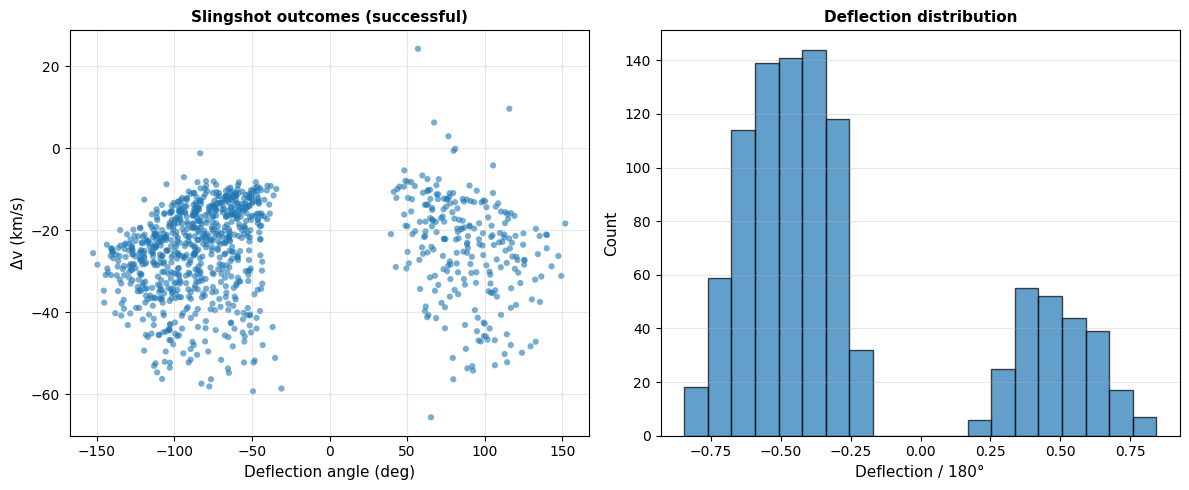


Monte Carlo Summary Statistics:
  Δv range: [-65.61, 24.22] km/s
  Δv mean: -25.03 ± 11.45 km/s
  Deflection range: [-152.4, 152.0]°
  Deflection mean: -44.2 ± 79.4°


In [ ]:
fig = plot_mc_summary(mc, figsize=(12, 5))
fig.savefig(output_dir / "mc_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"  Saved: {output_dir / 'mc_summary.png'}")

# Print statistics
delta_v_success = mc["delta_v"][mc["ok"]]
deflection_success = mc["deflection"][mc["ok"]]

print(f"\nMonte Carlo Summary Statistics:")
print(f"  Δv range: [{delta_v_success.min():.2f}, {delta_v_success.max():.2f}] km/s")
print(f"  Δv mean: {delta_v_success.mean():.2f} ± {delta_v_success.std():.2f} km/s")
print(f"  Deflection range: [{deflection_success.min():.1f}, {deflection_success.max():.1f}]°")
print(f"  Deflection mean: {deflection_success.mean():.1f} ± {deflection_success.std():.1f}°")

## Phase 2: Top Candidate Selection

In [5]:
top_idx = select_top_indices(
    mc,
    top_frac=cfg.pipeline.top_frac,
    min_top=cfg.pipeline.min_top,
    metric="delta_v",
    sign=cfg.pipeline.select_sign,
)

print(f"Selected {len(top_idx)} top candidates (top {cfg.pipeline.top_frac*100:.0f}%)")
print(f"Indices: {top_idx}")

# Show top candidates
print("\nTop 5 candidates:")
for rank, idx in enumerate(top_idx[:5], 1):
    dv = mc["delta_v"][idx]
    defl = mc["deflection"][idx]
    print(f"  {rank}. MC#{idx}: Δv={dv:.2f} km/s, deflection={defl:.1f}°")

Selected 101 top candidates (top 10%)
Indices: [14155 22695 21074 12451 16367 16227 13340  9816 23102  9040 18316 13957
  4610 20509 19351 13459 22346 14364 14326 13868 15940 20897  5841  4840
 18410  8342  9541  4023  1615  4832  6787 14687 21427 13092 16299  8297
 19011 10910 18906  5793  1027 17555  5307 13702 17796  5394  2023 11388
 20873  2463 21973 19367   284  8347 22608  9273   738 23241 18212  2054
 20999  3426  2057   437  7247  2191   147  7183  7145 20679 11873 10361
 14361 21391 10789 23928 12327 11884 17812  1719 19490  1621 15134 14801
  5093  2246  8311 15970  8971 19179  1348 11161  9062  2918  5123  4315
  1534 21953  6335  3294 18000]

Top 5 candidates:
  1. MC#14155: Δv=24.22 km/s, deflection=57.0°
  2. MC#22695: Δv=9.61 km/s, deflection=115.9°
  3. MC#21074: Δv=6.25 km/s, deflection=67.4°
  4. MC#12451: Δv=2.90 km/s, deflection=76.6°
  5. MC#16367: Δv=-0.15 km/s, deflection=81.0°


## Phase 3: High-Resolution Re-run

Re-integrate top candidates at higher resolution.

In [6]:
import importlib
import slingshot.dynamics
importlib.reload(slingshot.dynamics)

from slingshot.dynamics import simulate_3body, init_hot_jupiter_barycentric
from slingshot.analysis import analyze_trajectory
from slingshot.constants import R_SUN

print(f"Re-running {len(top_idx)} candidates at high resolution...")
print(f"  Timespan: {cfg.pipeline.t_best_max_sec:.1e} s")
print(f"  Output points: {cfg.pipeline.n_eval_best}")
print(f"  Escape radius factor: {cfg.numerical.escape_radius_factor:.1f}×")
print(f"  ODE method: {cfg.numerical.ode_method}")
print(f"  Softening: {cfg.numerical.softening_km:.1f} km")

# Star filter for high-res candidates
R_star_km = cfg.system.R_star_Rsun * R_SUN
star_clearance_Rstar = cfg.numerical.star_min_clearance_Rstar
if star_clearance_Rstar is not None:
    star_clearance_km = star_clearance_Rstar * R_star_km
    print(f"  Star filter: r_min_star > {star_clearance_Rstar:.1f} R★ ({star_clearance_km:.0f} km)")
else:
    star_clearance_km = None

Y_sp0 = mc["Y_sp0"]
sat_states = mc["sat_states"]

sols_best = []
analyses_best = []
Y0_best = []
star_rejected = 0

for i, idx in enumerate(top_idx):
    if i % max(1, len(top_idx)//10) == 0:
        print(f"  Progress: {i+1}/{len(top_idx)}")
    
    # Reconstruct initial state
    xs, ys, vxs, vys, xp, yp, vxp, vyp = Y_sp0
    x3, y3, vx3, vy3 = sat_states[idx]
    Y0 = np.array([xs, ys, vxs, vys, xp, yp, vxp, vyp, x3, y3, vx3, vy3], dtype=float)
    
    # Escape radius: particle's initial barycentric distance × escape_radius_factor
    r0_bary = np.sqrt(x3**2 + y3**2)
    escape_r = r0_bary * cfg.numerical.escape_radius_factor
    
    # Integrate at high resolution (with terminal event for escape)
    sol = simulate_3body(
        Y0,
        (0.0, cfg.pipeline.t_best_max_sec),
        m_star=m_star,
        m_p=m_p,
        n_eval=cfg.pipeline.n_eval_best,
        rtol=cfg.numerical.rtol,
        atol=cfg.numerical.atol,
        escape_radius_km=escape_r,
        method=cfg.numerical.ode_method,
        softening_km=cfg.numerical.softening_km,
    )
    
    # Analyze
    ana = analyze_trajectory(
        sol,
        frame="barycentric",
        m_star=m_star,
        m_p=m_p,
        R_p=R_p,
        r_far_factor=cfg.numerical.r_far_factor,
        min_clearance_factor=cfg.numerical.min_clearance_factor,
    )
    
    # Post-hoc star filter on high-res candidates
    if ana is not None and star_clearance_km is not None:
        enc_hr = ana.get("encounter")
        if enc_hr is not None and enc_hr.r_star_min is not None:
            if enc_hr.r_star_min < star_clearance_km:
                ana = None  # Mark as invalid
                star_rejected += 1
    
    sols_best.append(sol)
    analyses_best.append(ana)
    Y0_best.append(Y0)

valid_count = sum(1 for a in analyses_best if a is not None)
print(f"Re-run complete: {valid_count}/{len(top_idx)} valid")
if star_rejected > 0:
    print(f"  Star-proximity rejected: {star_rejected}")

Re-running 101 candidates at high resolution...
  Timespan: 5.0e+07 s
  Output points: 0
  Escape radius factor: 3.0×
  ODE method: DOP853
  Softening: 1000.0 km
  Star filter: r_min_star > 2.0 R★ (5651520 km)
  Progress: 1/101
  Progress: 11/101
  Progress: 21/101
  Progress: 31/101
  Progress: 41/101
  Progress: 51/101
  Progress: 61/101
  Progress: 71/101
  Progress: 81/101
  Progress: 91/101
  Progress: 101/101
Re-run complete: 101/101 valid


## Phase 4: Detailed Analysis & Visualization

### Best Candidate Trajectory

In [7]:
from slingshot.constants import R_SUN
R_star = cfg.system.R_star_Rsun * R_SUN

def _print_candidate(label, ana, orig_idx):
    enc = ana["encounter"]
    r_star_min_val = enc.r_star_min if enc and enc.r_star_min is not None else float('nan')
    print(f"{'='*60}")
    print(f"  {label}  (MC index #{orig_idx})")
    print(f"{'='*60}")
    print(f"  Δv (scalar):     {ana['delta_v']:>10.2f} km/s  ({ana['delta_v_pct']:+.1f}%)")
    print(f"  |ΔV_vec|:        {ana.get('delta_v_vec', float('nan')):>10.2f} km/s")
    print(f"  ½|ΔV_vec|²:      {ana.get('energy_half_dv_vec_sq', float('nan')):>10.2f} km²/s²")
    print(f"  Deflection:      {ana['deflection']:>10.1f}°  ({ana['deflection_frac']:.3f}×180)")
    print(f"  r_min (planet):  {ana['r_min']:>10.0f} km  ({ana['r_min']/R_p:.1f} R_p)")
    print(f"  r_min (star):    {r_star_min_val:>10.0f} km  ({r_star_min_val/R_star:.1f} R★)")
    print(f"  Impact param:    {ana['impact_parameter']:>10.0f} km")
    print(f"  Unbound (final): {str(ana['unbound_f']):>10s}")
    print(f"  ε_i:             {ana['eps_i']:>10.3e} km²/s²")
    print(f"  ε_f:             {ana['eps_f']:>10.3e} km²/s²")
    # Planet-frame diagnostics (energy extraction analysis)
    dvpf = ana.get('delta_v_planet_frame', None)
    if dvpf is not None:
        print(f"  --- Planet-frame diagnostics ---")
        print(f"  v_rel planet (in):  {ana.get('v_rel_planet_in', float('nan')):>8.2f} km/s")
        print(f"  v_rel planet (out): {ana.get('v_rel_planet_out', float('nan')):>8.2f} km/s")
        print(f"  Δv planet frame:    {dvpf:>8.2f} km/s  (0 = pure 2-body; ≠0 = star effect)")
        print(f"  Planet deflection:  {ana.get('planet_deflection_deg', float('nan')):>8.1f}°")
        efpo = ana.get('energy_from_planet_orbit', float('nan'))
        print(f"  ε from planet orbit: {efpo:>8.3e} km²/s²  (energy extracted from binary KE)")
        print(f"  Δε monopole:        {ana.get('delta_eps_monopole', float('nan')):>8.3e} km²/s²")

# --- Best by scalar Δv (speed change) — primary metric ---
valid_best = [(i, analyses_best[i]) for i in range(len(analyses_best)) if analyses_best[i] is not None]
if not valid_best:
    print("ERROR: No valid candidates after star filter!")
else:
    best_local_idx = max(valid_best, key=lambda x: x[1]["delta_v"])[0]
    best_sol = sols_best[best_local_idx]
    best_ana = analyses_best[best_local_idx]
    best_original_idx = top_idx[best_local_idx]
    
    _print_candidate("BEST by scalar Δv (|v_f| − |v_i|)", best_ana, best_original_idx)
    
    # --- Best by vector |ΔV_vec| (scattering energy) ---
    best_vec_local_idx = max(valid_best, key=lambda x: x[1].get("delta_v_vec", 0))[0]
    best_vec_sol = sols_best[best_vec_local_idx]
    best_vec_ana = analyses_best[best_vec_local_idx]
    best_vec_original_idx = top_idx[best_vec_local_idx]
    
    if best_vec_local_idx != best_local_idx:
        print()
        _print_candidate("BEST by |ΔV_vec| (scattering)", best_vec_ana, best_vec_original_idx)
    else:
        print(f"\n  (Same candidate is best by both metrics)")
    print("="*60)

  BEST by scalar Δv (|v_f| − |v_i|)  (MC index #14155)
  Δv (scalar):          24.22 km/s  (+24.2%)
  |ΔV_vec|:            109.04 km/s
  ½|ΔV_vec|²:         5944.54 km²/s²
  Deflection:            57.0°  (0.317×180)
  r_min (planet):      221875 km  (2.7 R_p)
  r_min (star):       9256129 km  (3.3 R★)
  Impact param:      15349225 km
  Unbound (final):       True
  ε_i:              3.077e+03 km²/s²
  ε_f:              7.069e+03 km²/s²
  --- Planet-frame diagnostics ---
  v_rel planet (in):     61.96 km/s
  v_rel planet (out):   157.17 km/s
  Δv planet frame:       95.21 km/s  (0 = pure 2-body; ≠0 = star effect)
  Planet deflection:      93.9°
  ε from planet orbit: -4.818e-02 km²/s²  (energy extracted from binary KE)
  Δε monopole:        3.992e+03 km²/s²

  BEST by |ΔV_vec| (scattering)  (MC index #22695)
  Δv (scalar):           9.61 km/s  (+9.2%)
  |ΔV_vec|:            185.93 km/s
  ½|ΔV_vec|²:        17284.68 km²/s²
  Deflection:           115.9°  (0.644×180)
  r_min (planet):    

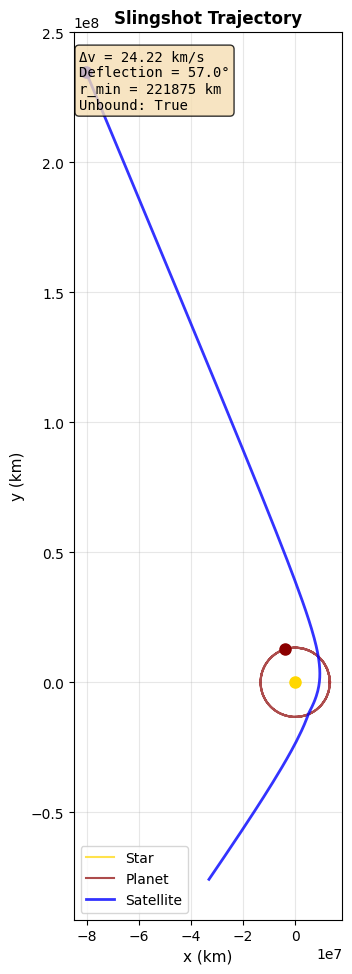

In [ ]:
fig = plot_best_candidate_with_bodies(best_sol, best_ana, m_star=m_star, m_p=m_p, R_p=R_p)
fig.savefig(output_dir / "best_candidate.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"  Saved: {output_dir / 'best_candidate.png'}")

### Phase-Space Analysis

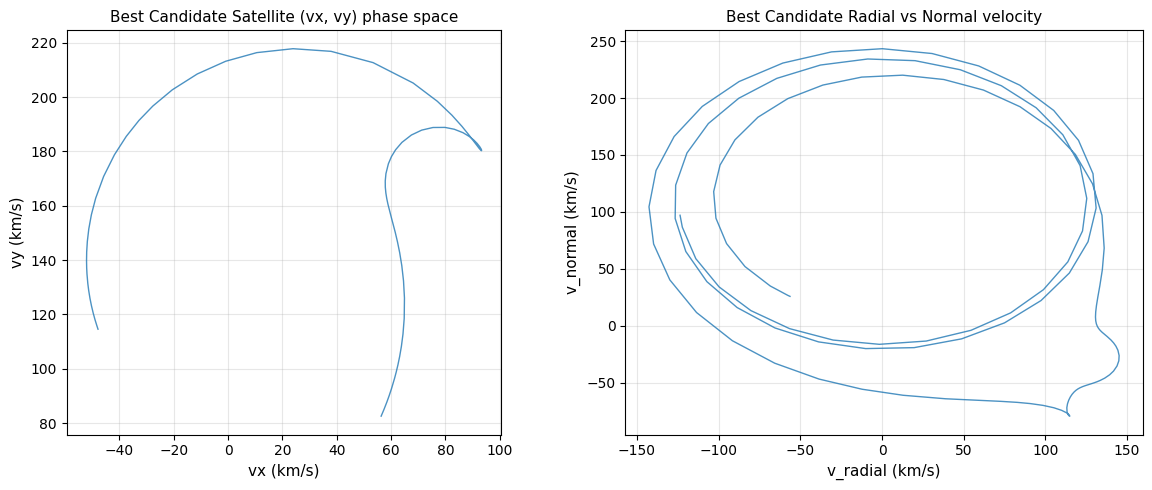

In [ ]:
from slingshot.plotting import plot_velocity_phase_space

fig = plot_velocity_phase_space(best_sol, title_prefix="Best Candidate", figsize=(12, 5))
fig.savefig(output_dir / "velocity_phase_space.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"  Saved: {output_dir / 'velocity_phase_space.png'}")

### Baseline Comparison

Compare with 2-body hyperbola and monopole baselines.

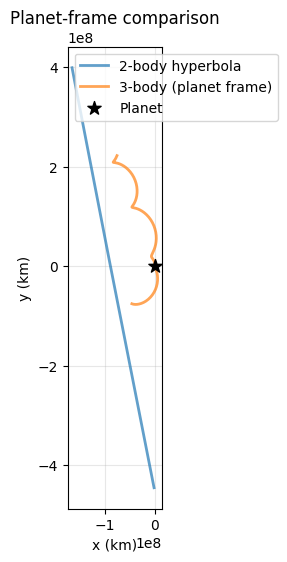

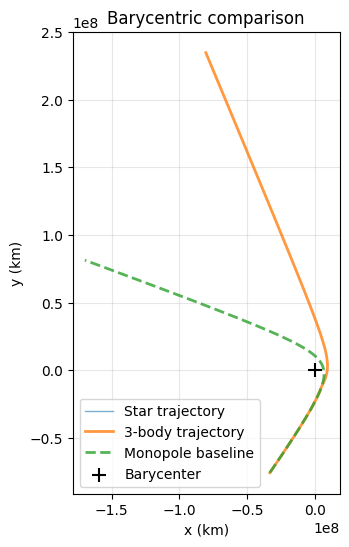


Baseline Comparison Results:
  2-body deflection (planet hyperbola): 0.2°
  3-body deflection (barycentric):      57.0°
  Extra Δε from planet presence:        3.992e+03 km²/s²
  2-body periapsis:  88260130 km  (1068.9 R_p)
  2-body eccentricity:  513.40


In [ ]:
from slingshot.analysis import extract_encounter_states

# Extract encounter geometry
enc = extract_encounter_states(
    best_sol,
    m_p=m_p,
    R_p=R_p,
    r_far_factor=cfg.numerical.r_far_factor,
    min_clearance_factor=cfg.numerical.min_clearance_factor,
)

if enc.ok:
    # Compare with baselines
    comparison = compare_3body_with_baselines(
        best_sol,
        enc,
        m_star=m_star,
        m_p=m_p,
        R_p=R_p,
        make_plots=True,
        plot_save_dir=str(output_dir),
    )
    
    if comparison["ok"]:
        tb = comparison["two_body"]
        print(f"\nBaseline Comparison Results:")
        print(f"  2-body deflection (planet hyperbola): {tb['deflection_deg']:.1f}°")
        print(f"  3-body deflection (barycentric):      {comparison['deflection_3body']:.1f}°")
        print(f"  Extra Δε from planet presence:        {comparison['extra_eps_from_planet']:.3e} km²/s²")
        if tb['hyperbolic']:
            print(f"  2-body periapsis:  {tb['r_p']:.0f} km  ({tb['r_p']/R_p:.1f} R_p)")
            print(f"  2-body eccentricity:  {tb['e']:.2f}")
else:
    print(f"Encounter extraction failed: {enc.reason}")

### Animation/Video Generation

Create animation frames for visual analysis.

In [11]:
if cfg.visualization.render_video:
    print(f"Generating animations...")
    print(f"  Output dir: ./frames")
    print(f"  Format: {cfg.visualization.video_format}")
    print(f"  FPS: {cfg.visualization.video_fps}")
    
    animations = generate_all_animations(
        best_sol,
        output_dir="./frames",
        video_fps=cfg.visualization.video_fps,
        video_format=cfg.visualization.video_format,
        animate_trajectory=cfg.visualization.animate_trajectory,
        animate_phase_space=cfg.visualization.animate_phase_space,
    )
    
    for anim_type, filepath in animations.items():
        if filepath:
            print(f"  ✓ {anim_type}: {filepath}")
        else:
            print(f"  ✗ {anim_type}: Failed")
else:
    print("Video rendering disabled in config.")

Video rendering disabled in config.


## Exploratory Analysis: All Candidates

In [12]:
# Create comparison table of all re-run candidates
candidates_table = []
for i, (idx, sol, ana) in enumerate(zip(top_idx, sols_best, analyses_best)):
    if ana:
        enc_i = ana.get("encounter")
        r_star_min_i = enc_i.r_star_min if enc_i and enc_i.r_star_min is not None else float('nan')
        candidates_table.append({
            'Rank': i+1,
            'MC_idx': idx,
            'Δv (km/s)': f"{ana['delta_v']:.2f}",
            'Δv (%)': f"{ana['delta_v_pct']:.1f}",
            'Deflection (°)': f"{ana['deflection']:.1f}",
            'r_min_planet (km)': f"{ana['r_min']:.0f}",
            'r_min_star (km)': f"{r_star_min_i:.0f}",
        })

import pandas as pd
df = pd.DataFrame(candidates_table)
print("\nTop Candidates Summary:")
print(df.to_string(index=False))


Top Candidates Summary:
 Rank  MC_idx Δv (km/s) Δv (%) Deflection (°) r_min_planet (km) r_min_star (km)
    1   14155     24.22   24.2           57.0            221875         9256129
    2   22695      9.61    9.2          115.9            160639        11668058
    3   21074      6.25    4.6           67.4            299442        11910532
    4   12451      2.90    2.2           76.6            413700         9541933
    5   16367     -0.15   -0.1           81.0            634321         5667381
    6   16227     -0.65   -0.6           80.0            941428        13678888
    7   13340     -1.24   -1.3          -83.4            144620         8891614
    8    9816     -4.22   -4.5          105.4            889207        10124261
    9   23102     -5.43   -3.8           48.2            963790        11343673
   10    9040     -6.67   -4.5           59.8            642542        11670831
   11   18316     -7.07   -5.5          -93.8             90324         8428022
   12   13957  

## Save Configuration & Results

Store configuration and results for reproducibility.

In [ ]:
from slingshot.config import save_config
import pickle
import dataclasses

# output_dir was already created after the MC cell — reuse it
print(f"Saving to: {output_dir}")

# Save config
config_file = output_dir / "config.yaml"
save_config(cfg, str(config_file), format="yaml")
print(f"✓ Config saved: {config_file}")

# Deep-convert dataclass instances to plain dicts (avoids PicklingError after importlib.reload)
def _strip_dataclasses(obj):
    if dataclasses.is_dataclass(obj) and not isinstance(obj, type):
        return {k: _strip_dataclasses(v) for k, v in dataclasses.asdict(obj).items()}
    if isinstance(obj, dict):
        return {k: _strip_dataclasses(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [_strip_dataclasses(v) for v in obj]
    return obj

# Save results
results_file = output_dir / "results.pkl"
with open(results_file, 'wb') as f:
    pickle.dump(_strip_dataclasses({
        'mc': mc,
        'top_indices': top_idx,
        'sols_best': sols_best,
        'analyses_best': analyses_best,
    }), f)
print(f"✓ Results saved: {results_file}")

# Save summary table
summary_file = output_dir / "summary.csv"
df.to_csv(summary_file, index=False)
print(f"✓ Summary saved: {summary_file}")

print(f"\nAll outputs in: {output_dir}")

✓ Config saved: results_Kepler-432_20260209_154118\config.yaml
✓ Results saved: results_Kepler-432_20260209_154118\results.pkl
✓ Summary saved: results_Kepler-432_20260209_154118\summary.csv

All outputs in: results_Kepler-432_20260209_154118


## Phase 5: Cross-Solver Comparison — Narrowed Baselines (v2.2)

Run the closed-form 2-body baselines using **velocity-matched** parameter envelopes
derived from the top 3-body candidates.  This ensures the 2-body ceilings are computed
at the same approach speeds the 3-body solver actually explored, eliminating the
v_approach mismatch from v2.1.

**Pipeline:**
1. Extract encounter parameters (v_approach, b, angle, vstar0) from top 3-body analyses
2. Pad ranges by a configurable factor (default 1.5×)
3. Sweep TwoBodyScatter over the padded envelope for both star and planet scattering
4. Compare using **both** ε (specific orbital energy) and **|ΔV_vec|** (vector ΔV magnitude)

In [14]:
# Reload slingshot modules (ensures latest code is picked up)
import importlib
import slingshot.config, slingshot.comparison, slingshot.analysis, slingshot.twobody
importlib.reload(slingshot.analysis)
importlib.reload(slingshot.twobody)
importlib.reload(slingshot.config)
importlib.reload(slingshot.comparison)

# Force reload narrowed_baselines (new module)
import slingshot.narrowed_baselines
importlib.reload(slingshot.narrowed_baselines)

from slingshot.narrowed_baselines import compute_narrowed_baselines, extract_envelope
from slingshot.comparison import compare_2body_3body, print_comparison

# --- Re-analyze top candidates with updated analysis.py ---
from slingshot.analysis import analyze_trajectory
from slingshot.constants import R_SUN

# Star filter threshold for re-analysis
R_star_km = cfg.system.R_star_Rsun * R_SUN
star_clearance_Rstar = cfg.numerical.star_min_clearance_Rstar
star_clearance_km = star_clearance_Rstar * R_star_km if star_clearance_Rstar is not None else None

analyses_best_v2 = []
star_filtered_v2 = 0
for sol in sols_best:
    ana_v2 = analyze_trajectory(
        sol, frame="barycentric",
        m_star=m_star, m_p=m_p, R_p=R_p,
        r_far_factor=cfg.numerical.r_far_factor,
        min_clearance_factor=cfg.numerical.min_clearance_factor,
    )
    # Apply star filter
    if ana_v2 is not None and star_clearance_km is not None:
        enc_v2_chk = ana_v2.get("encounter")
        if enc_v2_chk is not None and enc_v2_chk.r_star_min is not None:
            if enc_v2_chk.r_star_min < star_clearance_km:
                ana_v2 = None
                star_filtered_v2 += 1
    analyses_best_v2.append(ana_v2)

valid_count = sum(1 for a in analyses_best_v2 if a is not None)
print(f"Re-analyzed {len(sols_best)} top candidates → {valid_count} valid (v2.3 fields)")
if star_filtered_v2 > 0:
    print(f"  Star-proximity filtered: {star_filtered_v2}")

# Best by scalar Δv (primary metric for interstellar slingshot)
valid_v2 = [(i, a) for i, a in enumerate(analyses_best_v2) if a is not None]
if not valid_v2:
    print("ERROR: No valid candidates after filtering!")
    best_ana_v2 = None
    best_vec_ana_v2 = None
else:
    best_local_idx_v2 = max(valid_v2, key=lambda x: x[1]["delta_v"])[0]
    best_ana_v2 = analyses_best_v2[best_local_idx_v2]
    best_original_idx = top_idx[best_local_idx_v2]

    # Best by ½|ΔV_vec|² (scattering energy)
    best_vec_idx_v2 = max(valid_v2, key=lambda x: x[1]["energy_half_dv_vec_sq"])[0]
    best_vec_ana_v2 = analyses_best_v2[best_vec_idx_v2]

    print(f"\nBest by scalar Δv (MC#{best_original_idx}):")
    print(f"  delta_v (scalar |v_f|-|v_i|)  = {best_ana_v2['delta_v']:.4f} km/s")
    print(f"  delta_v_vec (|v_f - v_i|)     = {best_ana_v2['delta_v_vec']:.4f} km/s")
    print(f"  energy ½|ΔV_vec|²             = {best_ana_v2['energy_half_dv_vec_sq']:.4f} km²/s²")
    # Planet-frame diagnostics
    dvpf = best_ana_v2.get('delta_v_planet_frame', None)
    if dvpf is not None:
        print(f"  Δv planet frame               = {dvpf:.4f} km/s")
        print(f"  ε from planet orbit            = {best_ana_v2.get('energy_from_planet_orbit', float('nan')):.4e} km²/s²")

    print(f"\nBest by ½|ΔV_vec|² (MC#{top_idx[best_vec_idx_v2]}):")
    print(f"  delta_v (scalar |v_f|-|v_i|)  = {best_vec_ana_v2['delta_v']:.4f} km/s")
    print(f"  delta_v_vec (|v_f - v_i|)     = {best_vec_ana_v2['delta_v_vec']:.4f} km/s")
    print(f"  energy ½|ΔV_vec|²             = {best_vec_ana_v2['energy_half_dv_vec_sq']:.4f} km²/s²")
    print(f"  deflection                    = {best_vec_ana_v2['deflection']:.1f}°")
    enc_v2 = best_vec_ana_v2["encounter"]
    if enc_v2.star_v_bary_in is not None:
        print(f"  star v_bary at encounter      = {np.linalg.norm(enc_v2.star_v_bary_in):.4f} km/s")
    r_star_v2 = enc_v2.r_star_min if enc_v2 and enc_v2.r_star_min is not None else float('nan')
    print(f"  r_min (star)                  = {r_star_v2:.0f} km ({r_star_v2/R_star_km:.1f} R★)")

Re-analyzed 101 top candidates → 101 valid (v2.3 fields)

Best by scalar Δv (MC#14155):
  delta_v (scalar |v_f|-|v_i|)  = 24.2203 km/s
  delta_v_vec (|v_f - v_i|)     = 109.0371 km/s
  energy ½|ΔV_vec|²             = 5944.5442 km²/s²
  Δv planet frame               = 95.2066 km/s
  ε from planet orbit            = -4.8180e-02 km²/s²

Best by ½|ΔV_vec|² (MC#22695):
  delta_v (scalar |v_f|-|v_i|)  = 9.6096 km/s
  delta_v_vec (|v_f - v_i|)     = 185.9284 km/s
  energy ½|ΔV_vec|²             = 17284.6839 km²/s²
  deflection                    = 115.9°
  star v_bary at encounter      = 0.4518 km/s
  r_min (star)                  = 11668058 km (4.1 R★)


### Narrowed 2-Body Baselines (velocity-matched)

In [15]:
# --- Compute narrowed baselines from top 3-body candidates ---
# Filter to valid analyses only
valid_analyses = [a for a in analyses_best_v2 if a is not None]

narrowed = compute_narrowed_baselines(
    analyses_top=valid_analyses,
    cfg=cfg,
    padding_factor=1.5,
    num_v=20,
    num_b=100,
    num_angles=100,
)

# Store results for CDF — use ½|ΔV_vec|² (body-dependent scattering energy)
# NOT max_epsilon which is ½v∞² (body-independent approach KE)
E_star_narrowed   = narrowed["star"].max_energy_half_dv_vec_sq   if narrowed["star"]   else None
E_planet_narrowed = narrowed["planet"].max_energy_half_dv_vec_sq if narrowed["planet"] else None
dv_vec_star  = narrowed["star"].max_deltaV_vec   if narrowed["star"]   else None
dv_vec_planet = narrowed["planet"].max_deltaV_vec if narrowed["planet"] else None

# 3-body best metrics — use best-by-½|ΔV_vec|² candidate (not best-by-scalar-Δv)
E_3body = best_vec_ana_v2["energy_half_dv_vec_sq"] if best_vec_ana_v2 else 0.0
dv_vec_3body = best_vec_ana_v2["delta_v_vec"] if best_vec_ana_v2 else 0.0

Envelope (101 candidates, padding=1.5x):
  v_approach : [0.10, 312.67] km/s
  b          : [7.03e+06, 2.82e+07] km
  angle      : [-268.6°, 269.5°]
  vstar0     : 0.45 km/s
[star] Narrowed sweep: 20×100×100 = 200000 encounters …
  40000/200000 (2700 valid) …
  80000/200000 (29600 valid) …
  120000/200000 (68900 valid) …
  160000/200000 (108900 valid) …
  200000/200000 (148900 valid) …
[star] Complete: 148900/200000 successful
[planet] Narrowed sweep: 20×100×100 = 200000 encounters …
  40000/200000 (30000 valid) …
  80000/200000 (70000 valid) …
  120000/200000 (110000 valid) …
  160000/200000 (150000 valid) …
  200000/200000 (190000 valid) …
[planet] Complete: 190000/200000 successful
  NARROWED BASELINE COMPARISON
  Parameter envelope derived from top 3-body candidates
Envelope (101 candidates, padding=1.5x):
  v_approach : [0.10, 312.67] km/s
  b          : [7.03e+06, 2.82e+07] km
  angle      : [-268.6°, 269.5°]
  vstar0     : 0.45 km/s
-----------------------------------------------

### Formal Comparison Table (ε + vector ΔV)

In [16]:
# Build unified comparison dict with both metrics
# Uses best-by-½|ΔV_vec|² candidate for the 3-body column
comp = compare_2body_3body(
    # ε = ½v∞² (approach KE) — now correctly using max_epsilon, not ½|ΔV|²
    energy_2body_star=narrowed["star"].max_epsilon if narrowed["star"] else None,
    energy_2body_planet=narrowed["planet"].max_epsilon if narrowed["planet"] else None,
    energy_3body=E_3body,
    # Scalar ΔV baselines (best achievable |v_f| - |v_i| from 2-body sweeps)
    dv_2body_star=dv_vec_star,    # star vector ΔV as upper bound
    dv_2body_planet=dv_vec_planet, # planet vector ΔV as upper bound
    dv_3body=best_vec_ana_v2["delta_v"] if best_vec_ana_v2 else None,
    # Vector ΔV
    dv_vec_2body_star=dv_vec_star,
    dv_vec_2body_planet=dv_vec_planet,
    dv_vec_3body=dv_vec_3body,
    envelope_summary=narrowed["envelope"].summary() if narrowed["envelope"] else None,
    baseline_mode="narrowed",
)
print_comparison(comp)

  2-BODY  vs  3-BODY  COMPARISON
  All energies in km²/s² ≡ MJ/kg

--- ½|ΔV_vec|²  (scattering energy, body-dependent) ---
  Star  2-body max ½|ΔV|²  : 22447.42 km²/s² (22447.42 MJ/kg)
  Planet 2-body max ½|ΔV|² : 57.3285 km²/s² (57.3285 MJ/kg)
  3-body best ½|ΔV|²       : 17284.68 km²/s² (17284.68 MJ/kg)

--- ε = ½v∞²  (approach KE — same for any body at same speed) ---
  Star  baseline ε  : 48879.37 km²/s² (48879.37 MJ/kg)
  Planet baseline ε : 48880.94 km²/s² (48880.94 MJ/kg)
  3-body best ε     : 17284.68 km²/s² (17284.68 MJ/kg)
------------------------------------------------------------

  ΔV scalar (3-body best) : 9.61 km/s
  ΔV improvement (planet)  : -1.10 km/s
  ΔV improvement (star)    : -202.27 km/s

--- Scalar ΔV (|v_f| - |v_i|) ---
  Star  2-body max scalar ΔV    : 211.88 km/s
  Planet 2-body max scalar ΔV   : 10.71 km/s
  3-body best scalar ΔV         : 9.61 km/s

--- Vector ΔV (|v_f - v_i|) ---
  Star  2-body max |ΔV_vec|  : 211.88 km/s
  Planet 2-body max |ΔV_vec| : 10

### Energy CDF Overlay — Narrowed Baselines

Cumulative distribution of 3-body MC energies (½|ΔV_vec|²) against the
velocity-matched 2-body upper bounds.

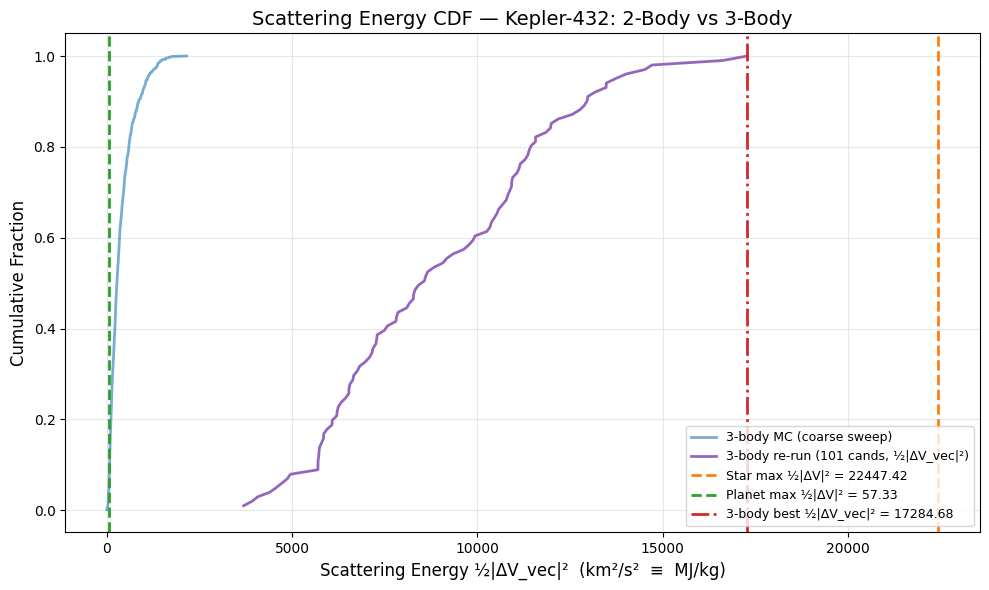


Coarse MC sweep (1010 particles):
  Exceeding star  ½|ΔV|² bound: 0.0%
  Exceeding planet ½|ΔV|² bound: 94.3%

High-res re-runs (101 candidates, ½|ΔV_vec|²):
  Exceeding star  ½|ΔV|² bound: 0/101 (0.0%)
  Exceeding planet ½|ΔV|² bound: 101/101 (100.0%)


In [ ]:
# --- Energy CDF: 3-body MC vs narrowed 2-body baselines ---
import matplotlib.pyplot as plt

# Coarse MC energies (using vector ΔV for consistency)
ok = mc["ok"]
# Re-compute with vector magnitude: for coarse MC we only have scalar delta_v
# Use ½ delta_v² as approximate energy (coarse only)
energies_mc_coarse = 0.5 * mc["delta_v"][ok] ** 2

# Re-run energies using the new vector ΔV metric
energies_rerun = np.array([
    a["energy_half_dv_vec_sq"] for a in analyses_best_v2 if a is not None
])

fig, ax = plt.subplots(figsize=(10, 6))

# 3-body CDF (coarse MC)
sorted_e = np.sort(energies_mc_coarse)
cdf = np.arange(1, len(sorted_e) + 1) / len(sorted_e)
ax.plot(sorted_e, cdf, linewidth=2, label="3-body MC (coarse sweep)", color="tab:blue", alpha=0.6)

# 3-body CDF (high-res re-runs, vector ΔV)
if len(energies_rerun) > 1:
    sorted_er = np.sort(energies_rerun)
    cdf_r = np.arange(1, len(sorted_er) + 1) / len(sorted_er)
    ax.plot(sorted_er, cdf_r, linewidth=2,
            label=f"3-body re-run ({len(energies_rerun)} cands, ½|ΔV_vec|²)",
            color="tab:purple", linestyle="-")

# Narrowed 2-body star baseline (now ½|ΔV_vec|², not ε)
if E_star_narrowed is not None:
    ax.axvline(E_star_narrowed, color="tab:orange", linestyle="--", linewidth=2,
               label=f"Star max ½|ΔV|² = {E_star_narrowed:.2f}")

# Narrowed 2-body planet baseline (now ½|ΔV_vec|², not ε)
if E_planet_narrowed is not None:
    ax.axvline(E_planet_narrowed, color="tab:green", linestyle="--", linewidth=2,
               label=f"Planet max ½|ΔV|² = {E_planet_narrowed:.2f}")

# 3-body best (vector ΔV energy)
ax.axvline(E_3body, color="tab:red", linestyle="-.", linewidth=2,
           label=f"3-body best ½|ΔV_vec|² = {E_3body:.2f}")

ax.set_xlabel("Scattering Energy ½|ΔV_vec|²  (km²/s²  ≡  MJ/kg)", fontsize=12)
ax.set_ylabel("Cumulative Fraction", fontsize=12)
ax.set_title(f"Scattering Energy CDF — {cfg.system.name}: 2-Body vs 3-Body", fontsize=14)
ax.legend(fontsize=9, loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(output_dir / "energy_cdf.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"  Saved: {output_dir / 'energy_cdf.png'}")

# Summary statistics
print(f"\nCoarse MC sweep ({len(energies_mc_coarse)} particles):")
if E_star_narrowed is not None:
    frac_above_star = (energies_mc_coarse > E_star_narrowed).sum() / len(energies_mc_coarse) * 100
    print(f"  Exceeding star  ½|ΔV|² bound: {frac_above_star:.1f}%")
if E_planet_narrowed is not None:
    frac_above_planet = (energies_mc_coarse > E_planet_narrowed).sum() / len(energies_mc_coarse) * 100
    print(f"  Exceeding planet ½|ΔV|² bound: {frac_above_planet:.1f}%")

print(f"\nHigh-res re-runs ({len(energies_rerun)} candidates, ½|ΔV_vec|²):")
if E_star_narrowed is not None:
    n_above = (energies_rerun > E_star_narrowed).sum()
    print(f"  Exceeding star  ½|ΔV|² bound: {n_above}/{len(energies_rerun)} "
          f"({n_above/len(energies_rerun)*100:.1f}%)")
if E_planet_narrowed is not None:
    n_above = (energies_rerun > E_planet_narrowed).sum()
    print(f"  Exceeding planet ½|ΔV|² bound: {n_above}/{len(energies_rerun)} "
          f"({n_above/len(energies_rerun)*100:.1f}%)")

In [19]:
# Verify: star speed is constant throughout the 3-body integration
vstar_initial = np.sqrt(vxs**2 + vys**2)
# Compare with encounter-time value from analysis
enc_v2 = best_ana_v2["encounter"]
vstar_encounter = np.linalg.norm(enc_v2.star_v_bary_in) if enc_v2.star_v_bary_in is not None else None

print(f"vstar0 (initial):   {vstar_initial:.6f} km/s")
print(f"vstar0 (encounter): {vstar_encounter:.6f} km/s")
print(f"Difference:         {abs(vstar_initial - vstar_encounter):.2e} km/s")

vstar0 (initial):   0.451803 km/s
vstar0 (encounter): 0.451803 km/s
Difference:         0.00e+00 km/s
